In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3)

20

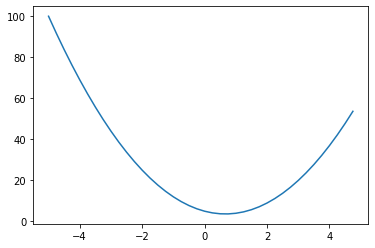

In [4]:
xs= np.arange(-5,5,0.25)
ys= f(xs)
plt.plot(xs,ys)

In [8]:
h=0.001
x=3
(f(x+h)-f(x))/h

14.00300000000243

In [9]:
f(3.001)

20.014003000000002

In [10]:
0.014003/.001

14.003

In [11]:
h= 0.001

a=2
b=-3
c=10

# slope of d wrt a  (diff)
d1 = a * b + c
a+=h
d2 = a * b + c
print('slope', (d2-d1)/h)
# diff wrt a will give b [dc/da=0], d(ab)/da = b(1)=b

slope -3.0000000000001137


In [12]:
h= 0.001

a=2
b=-3
c=10

# slope of d wrt b  (diff)
d1 = a * b + c
b+=h
d2 = a * b + c
print('slope', (d2-d1)/h)
# diff wrt b will give a [dc/db=0], d(ab)/db = a(1)=a

slope 1.9999999999997797


In [13]:
h= 0.001

a=2
b=-3
c=10

# slope of d wrt c  (diff)
d1 = a * b + c
c+=h
d2 = a * b + c
print('slope', (d2-d1)/h)
# diff wrt c will give 1 [d(ab)/dc=0], dc/dc=1

slope 0.9999999999994458


In [31]:
class Value:

    def __init__(self,data, _children =(),_op=''):
        self.data=data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self,other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), '*')
        return out
    
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c

In [26]:
a + b

Value(data=-1.0)

In [19]:
a*b

Value(data=-6.0)

In [27]:
a * b +c

Value(data=4.0)

In [32]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [33]:
d._op

'+'

In [34]:
d.data

4.0

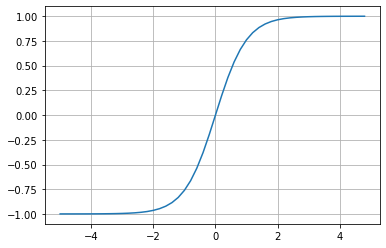

In [37]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [ ]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"